# Analisis Spasial & Klastering Risiko Putus Sekolah di Jawa Barat
### Kelompok 9 - II4013 Data Analytics
**Anggota Tim:**
1. Muhammad Zidni Alkindi (18223071) - Data Analyst / Modeler
2. Arqila Surya Putra (18223047) - Data Analyst / Modeler
3. Andhika Maulana A (18223005) - Visualization / Dashboard Developer
4. Muhammad Naufal Fathan (18223059) - Documentation and Insight Lead
5. Muhammad Farhan (18223004) - Data Engineer

---

## 1. Pendahuluan & Tahap O - Obtain
Pada tahap ini, kita mengimpor library yang diperlukan dan memeriksa berkas-berkas dataset mentah (`.xlsx`) yang disimpan di dalam direktori `data/raw/`:
1. **IPM 2024:** `Indeks Pembangunan Manusia Provinsi Jawa Barat 2024.xlsx` (BPS)
2. **Poverty 2024:** `Jumlah dan Persentase Penduduk Miskin Menurut Kabupaten_Kota di Provinsi Jawa Barat, 2024.xlsx` (BPS)
3. **Putus Sekolah:** `Tab-Putus-Sekolah.xlsx` (Disdik Jabar)
4. **ATS SD (Konteks Provinsi):** `jumlah-anak-tidak-sekolah-pada-sd-sederajat-dikarenakan-putus-sekolah-atau-lulus-tidak-melanjutkan-2024-sd-mi-sederajat.xlsx` (Kemendikdasmen)

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import pearsonr

# Set layout style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

raw_dir = "data/raw"
clean_dir = "data/clean"
print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Tahap S - Scrub: Pembersihan & Integrasi Data
Pada tahap ini, kita membersihkan masing-masing dataset:
- **IPM:** Slicing baris 48-74 untuk mengambil data tingkat Kabupaten/Kota Jawa Barat, merapikan whitespace, serta menyelaraskan nama wilayah.
- **Poverty:** Slicing baris 0-26, membuang kolom data September 2024 (karena kosong / tidak dipublikasikan tingkat wilayah), dan mengubah tipe data.
- **Putus Sekolah:** Slicing baris 5-31 untuk mengambil jumlah putus sekolah per wilayah untuk tingkat SD, SMP, SMA, SMK, dan SLB.

Semua nama Kabupaten/Kota diselaraskan ke format standar: `"Kab. <Nama>"` dan `"Kota <Nama>"`.

In [2]:
print("Scrubbing IPM...")
df_ipm_raw = pd.read_excel(os.path.join(raw_dir, "Indeks Pembangunan Manusia Provinsi Jawa Barat 2024.xlsx"))
df_ipm = df_ipm_raw.iloc[48:75, [1, 2, 3]].copy()
df_ipm.columns = ['Kab_Kota_Raw', 'IPM_2024', 'Laju_IPM']
df_ipm['IPM_2024'] = pd.to_numeric(df_ipm['IPM_2024'], errors='coerce')
df_ipm['Laju_IPM'] = pd.to_numeric(df_ipm['Laju_IPM'], errors='coerce')

def standardize_ipm(name):
    name = str(name).strip()
    if name.startswith("Kabupaten "):
        return name.replace("Kabupaten ", "Kab. ")
    return name
df_ipm['Kab_Kota'] = df_ipm['Kab_Kota_Raw'].apply(standardize_ipm)
df_ipm_final = df_ipm[['Kab_Kota', 'IPM_2024', 'Laju_IPM']].copy()

print("Scrubbing Poverty...")
df_poverty_raw = pd.read_excel(os.path.join(raw_dir, "Jumlah dan Persentase Penduduk Miskin Menurut Kabupaten_Kota di Provinsi Jawa Barat, 2024.xlsx"))
df_poverty = df_poverty_raw.iloc[:27, [0, 1, 3, 5]].copy()
df_poverty.columns = ['Kab_Kota_Raw', 'Garis_Kemiskinan_Maret', 'Jumlah_Miskin_Maret_Ribu', 'Persentase_Miskin_Maret']

def standardize_poverty(name):
    name = str(name).strip()
    if name.startswith("Kota "):
        return name
    return "Kab. " + name
df_poverty['Kab_Kota'] = df_poverty['Kab_Kota_Raw'].apply(standardize_poverty)
df_poverty_final = df_poverty[['Kab_Kota', 'Garis_Kemiskinan_Maret', 'Jumlah_Miskin_Maret_Ribu', 'Persentase_Miskin_Maret']].copy()

print("Scrubbing Putus Sekolah...")
df_ps_raw = pd.read_excel(os.path.join(raw_dir, "Tab-Putus-Sekolah.xlsx"), sheet_name='Tab-Putus-Sekolah')
df_ps = df_ps_raw.iloc[5:32, [2, 9, 15, 22, 29, 36]].copy()
df_ps.columns = ['Kab_Kota_Raw', 'Putus_SD', 'Putus_SMP', 'Putus_SMA', 'Putus_SMK', 'Putus_SLB']
df_ps['Kab_Kota'] = df_ps['Kab_Kota_Raw'].str.strip()
for col in ['Putus_SD', 'Putus_SMP', 'Putus_SMA', 'Putus_SMK', 'Putus_SLB']:
    df_ps[col] = pd.to_numeric(df_ps[col], errors='coerce').fillna(0).astype(int)
df_ps_final = df_ps[['Kab_Kota', 'Putus_SD', 'Putus_SMP', 'Putus_SMA', 'Putus_SMK', 'Putus_SLB']].copy()

print("Merging datasets...")
df_merged = df_ps_final.merge(df_ipm_final, on='Kab_Kota', how='inner')
df_merged = df_merged.merge(df_poverty_final, on='Kab_Kota', how='inner')
print(f"Integrated dataset shape: {df_merged.shape}")

Scrubbing IPM...
Scrubbing Poverty...
Scrubbing Putus Sekolah...


Merging datasets...
Integrated dataset shape: (27, 11)


### Feature Engineering
Kita membuat 5 fitur baru untuk menstandarkan ukuran dan analisis:
1. `Total_Putus_Sekolah`: Jumlah putus sekolah kumulatif seluruh jenjang.
2. `Jumlah_Miskin_Jiwa`: Konversi penduduk miskin dari ribuan ke jiwa.
3. `Estimasi_Total_Penduduk`: Menghitung estimasi total penduduk wilayah dengan membagi penduduk miskin dengan persentase kemiskinan.
4. `Rasio_Putus_Sekolah_per_Miskin`: Rasio anak putus sekolah terhadap jumlah penduduk miskin.
5. `Putus_Sekolah_per_10k_Penduduk`: Angka putus sekolah terstandar per 10.000 penduduk untuk perbandingan yang adil antar wilayah.

In [3]:
df_merged['Total_Putus_Sekolah'] = (
    df_merged['Putus_SD'] + 
    df_merged['Putus_SMP'] + 
    df_merged['Putus_SMA'] + 
    df_merged['Putus_SMK'] + 
    df_merged['Putus_SLB']
)
df_merged['Jumlah_Miskin_Jiwa'] = (df_merged['Jumlah_Miskin_Maret_Ribu'] * 1000).astype(int)
df_merged['Estimasi_Total_Penduduk'] = ((df_merged['Jumlah_Miskin_Jiwa'] * 100) / df_merged['Persentase_Miskin_Maret']).astype(int)
df_merged['Rasio_Putus_Sekolah_per_Miskin'] = df_merged['Total_Putus_Sekolah'] / df_merged['Jumlah_Miskin_Jiwa']
df_merged['Putus_Sekolah_per_10k_Penduduk'] = (df_merged['Total_Putus_Sekolah'] / df_merged['Estimasi_Total_Penduduk']) * 10000

# Export clean data
os.makedirs(clean_dir, exist_ok=True)
df_merged.to_csv(os.path.join(clean_dir, "dataset_bersih.csv"), index=False)
print("Master Table exported to data/clean/dataset_bersih.csv")
df_merged.head()

Master Table exported to data/clean/dataset_bersih.csv


,Kab_Kota,Putus_SD,Putus_SMP,Putus_SMA,Putus_SMK,Putus_SLB,IPM_2024,Laju_IPM,Garis_Kemiskinan_Maret,Jumlah_Miskin_Maret_Ribu,Persentase_Miskin_Maret,Total_Putus_Sekolah,Jumlah_Miskin_Jiwa,Estimasi_Total_Penduduk,Rasio_Putus_Sekolah_per_Miskin,Putus_Sekolah_per_10k_Penduduk
0,Kab. Bandung,345,19,4,0,10,74.59,0.76,455636,239.87,6.19,378,239870,3875121,0.001576,0.975453
1,Kab. Bandung Barat,195,7,11,16,12,70.77,0.63,455325,179.70,10.49,241,179700,1713060,0.001341,1.406839
2,Kab. Bekasi,545,8,6,9,0,76.80,0.88,674924,204.54,4.80,568,204540,4261250,0.002777,1.332942
3,Kab. Bogor,533,55,5,21,7,73.63,0.84,513512,446.79,7.05,621,446790,6337446,0.001390,0.979890
4,Kab. Ciamis,49,3,2,10,7,73.64,0.71,467497,90.79,7.39,71,90790,1228552,0.000782,0.577916


## 3. Tahap E - Explore: Eksplorasi Data & Analisis Korelasi
Di sini, kita menguji korelasi antara persentase penduduk miskin (`Persentase_Miskin_Maret`) dengan tingkat kerentanan putus sekolah terstandarisasi (`Putus_Sekolah_per_10k_Penduduk`).

Pearson Correlation Coefficient: 0.3944
P-value: 0.0418


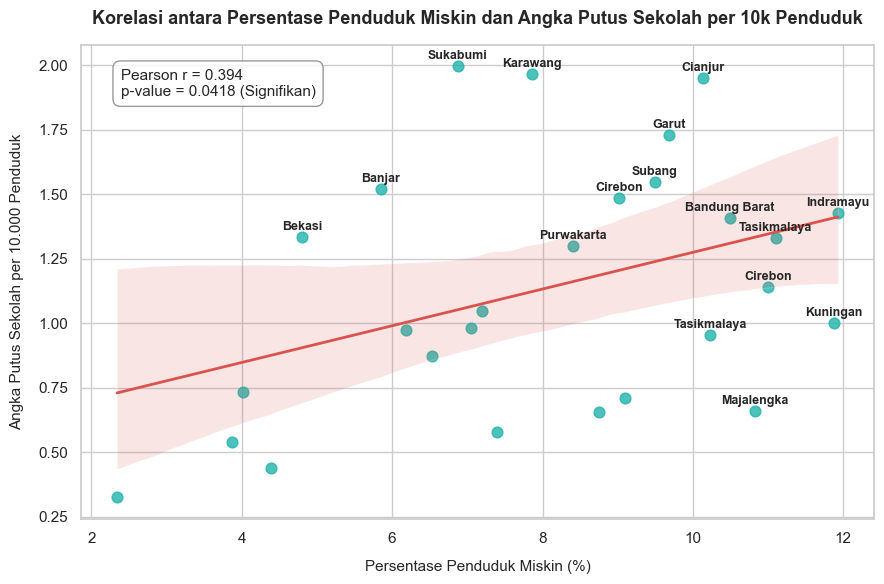

In [4]:
poverty_rate = df_merged['Persentase_Miskin_Maret']
dropout_rate = df_merged['Putus_Sekolah_per_10k_Penduduk']
corr_coeff, p_value = pearsonr(poverty_rate, dropout_rate)
print(f"Pearson Correlation Coefficient: {corr_coeff:.4f}")
print(f"P-value: {p_value:.4f}")

# Plotting correlation
plt.figure(figsize=(9, 6))
sns.regplot(x=poverty_rate, y=dropout_rate, 
            scatter_kws={'s': 60, 'alpha': 0.8, 'color': '#20b2aa'},
            line_kws={'color': '#d9534f', 'lw': 2})

plt.title("Korelasi antara Persentase Penduduk Miskin dan Angka Putus Sekolah per 10k Penduduk", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Persentase Penduduk Miskin (%)", fontsize=11, labelpad=10)
plt.ylabel("Angka Putus Sekolah per 10.000 Penduduk", fontsize=11, labelpad=10)

# Annotate correlation values
plt.text(0.05, 0.95, f"Pearson r = {corr_coeff:.3f}\np-value = {p_value:.4f} ({'Signifikan' if p_value < 0.05 else 'Tidak Signifikan'})", 
         transform=plt.gca().transAxes, fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.8, edgecolor='gray'))

# Label important points
for i, txt in enumerate(df_merged['Kab_Kota']):
    if df_merged.loc[i, 'Persentase_Miskin_Maret'] > 9.5 or df_merged.loc[i, 'Putus_Sekolah_per_10k_Penduduk'] > 1.3:
        plt.annotate(txt.replace("Kab. ", "").replace("Kota ", ""), 
                     (df_merged.loc[i, 'Persentase_Miskin_Maret'], df_merged.loc[i, 'Putus_Sekolah_per_10k_Penduduk']),
                     textcoords="offset points", xytext=(0,5), ha='center', fontsize=9, fontweight='semibold')

plt.tight_layout()
plt.show()

## 4. Tahap M - Model: Klastering Kerentanan Risiko (K-Means)
Kami memilih 3 fitur utama untuk menentukan profil risiko wilayah:
1. `Putus_Sekolah_per_10k_Penduduk` (Tingkat Putus Sekolah Terstandar)
2. `Persentase_Miskin_Maret` (Kondisi Kemiskinan Ekonomi)
3. `IPM_2024` (Indeks Pembangunan Manusia / Sosial Pembangunan)

Fitur-fitur ini distandarisasi terlebih dahulu menggunakan `StandardScaler` agar perbedaan skala tidak mendistorsi perhitungan jarak.

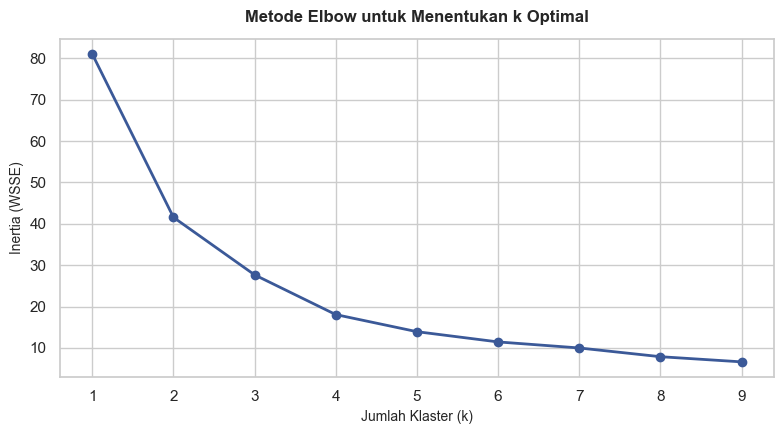

In [5]:
features = ['Putus_Sekolah_per_10k_Penduduk', 'Persentase_Miskin_Maret', 'IPM_2024']
X = df_merged[features].copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Evaluating number of clusters (Elbow Method)
inertia = []
k_range = range(1, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 4.5))
plt.plot(k_range, inertia, 'o-', color='#3b5998', lw=2)
plt.title("Metode Elbow untuk Menentukan k Optimal", fontsize=12, fontweight='bold', pad=12)
plt.xlabel("Jumlah Klaster (k)", fontsize=10)
plt.ylabel("Inertia (WSSE)", fontsize=10)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

### K-Means dengan k=3 & Evaluasi Silhouette Score
Mengelompokkan wilayah menjadi 3 Klaster Kerentanan: Risiko Tinggi, Risiko Sedang, dan Risiko Rendah.

In [6]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_merged['Cluster'] = kmeans.fit_predict(X_scaled)
score = silhouette_score(X_scaled, df_merged['Cluster'])
print(f"Silhouette Score for k=3: {score:.4f}")

# Menentukan Profil Risiko dari Rata-rata Fitur Klaster
centers = df_merged.groupby('Cluster')[features].mean()
print("Cluster Centers:")
print(centers)

# Mapping otomatis berdasarkan profile index (Semakin tinggi kemiskinan & putus sekolah dan rendah IPM = Risiko Tinggi)
norm_centers = (centers - centers.min()) / (centers.max() - centers.min())
norm_centers['IPM_2024'] = 1.0 - norm_centers['IPM_2024'] # Kebalikan IPM
rank = norm_centers.sum(axis=1).sort_values()
risk_mapping = {
    rank.index[0]: 'Risiko Rendah',
    rank.index[1]: 'Risiko Sedang',
    rank.index[2]: 'Risiko Tinggi'
}
df_merged['Tingkat_Kerentanan'] = df_merged['Cluster'].map(risk_mapping)
print("\nMapping Cluster:", risk_mapping)

Silhouette Score for k=3: 0.3409
Cluster Centers:
         Putus_Sekolah_per_10k_Penduduk  Persentase_Miskin_Maret   IPM_2024
Cluster                                                                    
0                              1.041762                 7.299091  75.279091
1                              1.425755                10.124167  71.465000
2                              0.509616                 3.652500  82.662500

Mapping Cluster: {np.int32(2): 'Risiko Rendah', np.int32(0): 'Risiko Sedang', np.int32(1): 'Risiko Tinggi'}


### Visualisasi Klaster Kerentanan

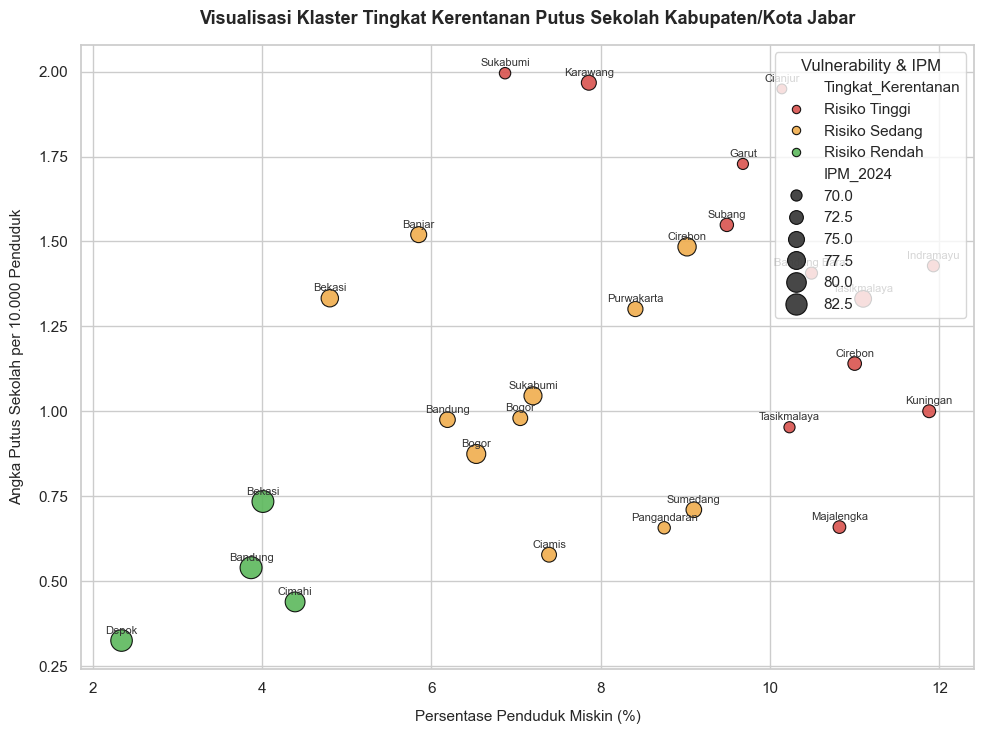

In [7]:
plt.figure(figsize=(10, 7.5))
colors = {'Risiko Tinggi': '#d9534f', 'Risiko Sedang': '#f0ad4e', 'Risiko Rendah': '#5cb85c'}

sns.scatterplot(
    data=df_merged,
    x='Persentase_Miskin_Maret',
    y='Putus_Sekolah_per_10k_Penduduk',
    hue='Tingkat_Kerentanan',
    hue_order=['Risiko Tinggi', 'Risiko Sedang', 'Risiko Rendah'],
    palette=colors,
    size='IPM_2024',
    sizes=(50, 250),
    alpha=0.9,
    edgecolor='black',
    linewidth=0.8
)

plt.title("Visualisasi Klaster Tingkat Kerentanan Putus Sekolah Kabupaten/Kota Jabar", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Persentase Penduduk Miskin (%)", fontsize=11, labelpad=10)
plt.ylabel("Angka Putus Sekolah per 10.000 Penduduk", fontsize=11, labelpad=10)
plt.legend(title='Vulnerability & IPM', loc='upper right')

for i, txt in enumerate(df_merged['Kab_Kota']):
    plt.annotate(txt.replace("Kab. ", "").replace("Kota ", ""), 
                 (df_merged.loc[i, 'Persentase_Miskin_Maret'], df_merged.loc[i, 'Putus_Sekolah_per_10k_Penduduk']),
                 textcoords="offset points", xytext=(0,5), ha='center', fontsize=8, color='#333333')

plt.tight_layout()
plt.show()

## 5. Ringkasan

### Profil Rata-rata Tiap Klaster:

In [8]:
summary = df_merged.groupby('Tingkat_Kerentanan')[features + ['Total_Putus_Sekolah']].mean()
summary

,Putus_Sekolah_per_10k_Penduduk,Persentase_Miskin_Maret,IPM_2024,Total_Putus_Sekolah
Tingkat_Kerentanan,,,,
Risiko Rendah,0.509616,3.652500,82.662500,122.750000
Risiko Sedang,1.041762,7.299091,75.279091,189.727273
Risiko Tinggi,1.425755,10.124167,71.465000,280.166667


### Anggota Setiap Klaster:

In [9]:
for risk_level in ['Risiko Tinggi', 'Risiko Sedang', 'Risiko Rendah']:
    members = df_merged[df_merged['Tingkat_Kerentanan'] == risk_level]['Kab_Kota'].tolist()
    print(f"{risk_level} (N = {len(members)}):")
    print(", ".join(members))
    print("-" * 50)

Risiko Tinggi (N = 12):
Kab. Bandung Barat, Kab. Cianjur, Kab. Cirebon, Kab. Garut, Kab. Indramayu, Kab. Karawang, Kab. Kuningan, Kab. Majalengka, Kab. Subang, Kab. Sukabumi, Kab. Tasikmalaya, Kota Tasikmalaya
--------------------------------------------------
Risiko Sedang (N = 11):
Kab. Bandung, Kab. Bekasi, Kab. Bogor, Kab. Ciamis, Kab. Pangandaran, Kab. Purwakarta, Kab. Sumedang, Kota Banjar, Kota Bogor, Kota Cirebon, Kota Sukabumi
--------------------------------------------------
Risiko Rendah (N = 4):
Kota Bandung, Kota Bekasi, Kota Cimahi, Kota Depok
--------------------------------------------------
